# Next Generation Reservoir Computing (NG-RC)
<a target="_blank" href="https://colab.research.google.com/github/Iam-Mak/ng-rc-modeling/blob/main/notbook/DoubleScrollNVAR-RK23.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook demonstrates the **Next Generation Reservoir Computing (NG-RC)** framework applied to the Chua Double-Scroll Chaotic Attractor .

The implementation follows the methodology introduced by:

Daniel J. Gauthier, Erik M. Bollt, Aaron D. Griffith,  
Wendson A. S. Barbosa,  
*Next Generation Reservoir Computing*, Nature Communications (2021).

---

## Modeling the Double Scroll Chaotic Attractor

### Objective

The aim of this section is to:

- Learn the dynamics of the **Double Scroll system** from data  
- Construct **Nonlinear Vector AutoRegression (NVAR)** features  
- Perform autonomous (closed-loop) prediction  
- Evaluate:
  - Short-term prediction accuracy  
  - Long-term system behavior  

### Procedure

- Generate time-series data from the **Double Scroll system** using numerical integration  
- Construct **NVAR features** using delayed states and nonlinear transformations  
- Train the model using linear regression  
- Perform autonomous prediction on unseen data  
- Evaluate prediction accuracy and the quality of the reconstructed dynamics  

In [1]:
# Source: DoubleScrollNVAR-RK23.py

import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import fsolve


#from mpl_toolkits.mplot3d import Axes3D
#import matplotlib.patches as mpatches

## 1. Simulation Setup

All time quantities are expressed in dimensionless simulation time units.

| Symbol | Value | Description |
|--------|--------|-------------|
| $dt$ | 0.25 | Time step size, $t_{n+1} = t_n + dt$ |
| $T_{\text{warmup}}$ | 1.0 | Transient period (discarded) |
| $T_{\text{train}}$ | 100.0 | Training duration |
| $T_{\text{test}}$ | 800.0 | Prediction duration |
| $T_{\text{total}}$ | 901.0 | Total simulation time, $T_{\text{warmup}} + T_{\text{train}} + T_{\text{test}}$ |
| $T_{\text{plot}}$ | 200 | Portion of prediction interval shown |
| $T_{\lambda}$ | 7.8125 | Lyapunov time |

In [2]:
## Parameters

# Time step of numerical integration
dt = 0.25

# Warm-up time (no training; allows transients to decay)
warmup = 1.0

# Training duration (used to learn output weights)
traintime = 100.0

# Testing duration (model prediction phase)
testtime = 800.0

# Total simulation time
maxtime = warmup + traintime + testtime

# Portion of test duration shown in plots
plottime = 200

# Lyapunov time of the Lorenz system (predictability scale)
lyaptime = 7.8125

### 1.1 Discrete Time Parameters

Time is discretized using a fixed step size $dt$.  
Each continuous time interval is converted into discrete samples by dividing by $dt$.

| Name | Symbol | Definition | Number of Samples |
|------|--------|------------|-------------------|
| Warmup samples | $N_{\text{warmup}}$ | $T_{\text{warmup}} / dt$ | 4 |
| Training samples | $N_{\text{train}}$ | $T_{\text{train}} / dt$ | 400 |
| Warmup + Training samples | $N_{\text{warm+train}}$ | $N_{\text{warmup}} + N_{\text{train}}$ | 404 |
| Testing samples | $N_{\text{test}}$ | $T_{\text{test}} / dt$ | 3200 |
| Total samples | $N_{\text{total}}$ | $T_{\text{total}} / dt$ | 3604 |
| Plot samples | $N_{\text{plot}}$ | $T_{\text{plot}} / dt$ | 800 |
| Samples per Lyapunov time | $N_{\lambda}$ | $T_{\lambda} / dt$ | 31 |

In [3]:
# Convert time durations to discrete sample counts

warmup_pts    = round(warmup / dt)        # Number of warm-up samples
traintime_pts = round(traintime / dt)     # Number of training samples
warmtrain_pts = warmup_pts + traintime_pts  # Samples before prediction
testtime_pts  = round(testtime / dt)      # Number of testing samples
maxtime_pts   = round(maxtime / dt)       # Total number of samples
plottime_pts  = round(plottime / dt)      # Samples shown in plots
lyaptime_pts  = round(lyaptime / dt)      # Lyapunov time in samples

# Display computed sample counts
print("warmup_pts    =", warmup_pts)
print("traintime_pts =", traintime_pts)
print("warmtrain_pts =", warmtrain_pts)
print("testtime_pts  =", testtime_pts)
print("maxtime_pts   =", maxtime_pts)
print("plottime_pts  =", plottime_pts)
print("lyaptime_pts  =", lyaptime_pts)

warmup_pts    = 4
traintime_pts = 400
warmtrain_pts = 404
testtime_pts  = 3200
maxtime_pts   = 3604
plottime_pts  = 800
lyaptime_pts  = 31


### 1.2 NVAR Feature Parameters

The following parameters determine the size and structure of the NVAR feature space built from delayed system states.

| Name | Symbol | Definition | Value |
|------|--------|------------|--------|
| Input dimension | $d$ | Number of state variables $(x, y, z)$ | 3 |
| Number of delay taps | $k$ | Number of time delay copies | 2 |
| Linear feature dimension | $d_{\text{lin}}$ | $k \cdot d$ | 6 |
| Cubic feature dimension | $d_{\text{nonlin}}$ | $\dfrac{d_{\text{lin}}(d_{\text{lin}} + 1)(d_{\text{lin}} + 2)}{6}$ | 56 |
| Total feature dimension | $d_{\text{tot}}$ | $d_{\text{lin}} + d_{\text{nonlin}}$ | 62 |

> **Note:** Unlike the Lorenz system, the Double Scroll system shows sharper transitions and more complex nonlinear behavior, which requires higher order (cubic) feature terms for accurate representation.

In [4]:
# NVAR feature parameters

d = 3                 # Input dimension
k = 2                 # Number of time delays

dlin = k * d          # Linear feature dimension
dnonlin = int(dlin*(dlin+1)*(dlin+2)/6)  # Cubic feature dimension

dtot = dlin + dnonlin  # Total feature dimension (linear + cubic)

# Display feature dimensions
print("d       =", d)
print("k       =", k)
print("dlin    =", dlin)
print("dnonlin =", dnonlin)
print("dtot    =", dtot)

d       = 3
k       = 2
dlin    = 6
dnonlin = 56
dtot    = 62


### 1.3 Regression and Discrete Time Grid

The following parameters specify the regression regularization and the discrete time grid over which the system is numerically integrated.

| Name                          | Symbol                | Definition |
|--------------------------------|-----------------------|------------|
| Ridge regularization parameter | $\alpha$              | Controls the amount of regularization |
| Time grid                      | $t_{\text{eval}}$     | $t_{\text{eval}} \in [0, T_{\text{total}}]$ with uniform spacing $dt$ |

In [5]:
# ridge parameter for regression
ridge_param = 1.e-3

# t values for whole evaluation time
# (need maxtime_pts + 1 to ensure a step of dt)
t_eval=np.linspace(0,maxtime,maxtime_pts+1)

print("First 5 time points:", t_eval[:5])
print("Last 5 time points :", t_eval[-5:])

First 5 time points: [0.   0.25 0.5  0.75 1.  ]
Last 5 time points : [900.   900.25 900.5  900.75 901.  ]


---
## 2. Double Scroll System

The Double Scroll system is a three-dimensional nonlinear dynamical system that exhibits chaotic behavior.

The state vector is defined as:

$$
\mathbf{x}(t)
=
\begin{bmatrix}
V_1(t) \\
V_2(t) \\
I(t)
\end{bmatrix}
$$

Define the voltage difference:

$$
\Delta V(t) = V_1(t) - V_2(t)
$$

The nonlinear conductance function is given by:

$$
g(\Delta V)
=
\frac{\Delta V}{r_2}
+
i_r \sinh\!\big(\alpha \Delta V\big)
$$

The system dynamics are:

$$
\begin{aligned}
\dot{V}_1(t) &= \frac{V_1(t)}{r_1} - g(\Delta V(t)) \\
\dot{V}_2(t) &= g(\Delta V(t)) - I(t) \\
\dot{I}(t)   &= V_2(t) - r_4 I(t)
\end{aligned}
$$

In [6]:
# Double Scroll system parameters
r1 = 1.2
r2 = 3.44
r4 = 0.193
alpha = 11.6
ir = 2 * 2.25e-5   # Scaling factor for sinh nonlinearity


def doublescroll(t, y):
    """
    Double Scroll (circuit-based) dynamical system.

    State variables:
        y[0] = V1 (voltage 1)
        y[1] = V2 (voltage 2)
        y[2] = I  (current)
    """

    # Voltage difference
    dV = y[0] - y[1]

    # Nonlinear conductance
    g = (dV / r2) + ir * np.sinh(alpha * dV)

    # System equations
    dV1 = (y[0] / r1) - g
    dV2 = g - y[2]
    dI  = y[1] - r4 * y[2]

    return [dV1, dV2, dI]


### 2.1 Generating Data from the Double Scroll System

The Double Scroll system is numerically integrated over 
$[0, T_{\text{total}}]$ with uniform time step $dt$:

$$
t_n = n\,dt, \quad n = 0, 1, \dots, N_{\text{total}}
$$

For simplicity, we set $N := N_{\text{total}}$ and use $N$ in the remainder of this section.

**Initial condition**
$$
(V_1(0), V_2(0), I(0)) = (0.37926545, 0.058339, -0.08167691)


$$

At each time step, the state vector is

$$
\mathbf{x}(t_n) =
\begin{bmatrix}
V_1(t_n) \\
V_2(t_n) \\
I(t_n)
\end{bmatrix}
$$

Collecting all states gives the data matrix

$$
\mathbf{X}
=
\begin{bmatrix}
\mathbf{x}(t_0) & \mathbf{x}(t_1) & \cdots & \mathbf{x}(t_N)
\end{bmatrix}
\in \mathbb{R}^{3 \times (N+1)}
$$

In [7]:
# Integrate the Double Scroll system to generate time-series data
# Initial condition lies on the attractor to ensure typical chaotic dynamics

doublescroll_soln = solve_ivp(
    doublescroll,                  # Double Scroll system function
    (0, maxtime),                  # Time interval
    [0.37926545,
     0.058339,
     -0.08167691],                 # Initial state [V1, V2, I]
    t_eval=t_eval,                 # Discrete evaluation times
    method='RK23'                  # Runge–Kutta method
)

print("Solution status:", doublescroll_soln.message)
print("State array shape:", doublescroll_soln.y.shape)

Solution status: The solver successfully reached the end of the integration interval.
State array shape: (3, 3605)


After numerical integration, the full trajectory is collected into the data matrix

$$
\mathbf{X}_{\text{total}}
=
\begin{bmatrix}
V_1(t_0) & V_1(t_1) & \cdots & V_1(t_{N}) \\
V_2(t_0) & V_2(t_1) & \cdots & V_2(t_{N}) \\
I(t_0)   & I(t_1)   & \cdots & I(t_{N})
\end{bmatrix}
\in \mathbb{R}^{3 \times (N + 1)}
$$

### 2.2 Total Variance

The total variance is computed as the sum of variances of each state variable 
($V_1$, $V_2$, $I$) over the entire trajectory:

$$
\mathrm{Var}_{\text{total}}
=
\mathrm{Var}\big(V_1(t_n)\big)_{n=0}^{N}
+
\mathrm{Var}\big(V_2(t_n)\big)_{n=0}^{N}
+
\mathrm{Var}\big(I(t_n)\big)_{n=0}^{N}
$$

This value is used to normalize the prediction error.

> **Note:** Unlike the Lorenz system, the Double Scroll variables have different scales, so the total variance is computed as the sum of individual variances for proper normalization.

In [8]:
# Compute total variance (used for NRMSE normalization)
total_var = (
    np.var(doublescroll_soln.y[0, :]) +
    np.var(doublescroll_soln.y[1, :]) +
    np.var(doublescroll_soln.y[2, :])
)

print("Total variance =", total_var)

Total variance = 2.507710274185966


---
## 3. NVAR Feature Construction

At each time step $t_n$, the NVAR feature vector is constructed as

$$
\mathbf{O}_{\text{tot}}(t_n) =
\begin{bmatrix}
\text{Linear + Delay Terms} \\
\text{Nonlinear Terms}
\end{bmatrix}
$$

- The linear features $\mathbf{O}_{\text{lin}}(t_n)$ include the current state variables and their delayed values.
- The nonlinear features $\mathbf{O}_{\text{nonlin}}(t_n)$ consist of higher-order polynomial combinations (products) of the linear features.

The complete feature vector is obtained by stacking these components and is used to train the NVAR model.

### 3.1 Linear and Delay Features

The linear feature vector at time $t_n$ consists of the current state 
variables and their delayed values:

$$
\mathbf{O}_{\text{lin}}(t_n)
=
\begin{bmatrix}
V_1(t_n) \\
V_2(t_n) \\
I(t_n) \\
V_1(t_{n-1}) \\
V_2(t_{n-1}) \\
I(t_{n-1})
\end{bmatrix}
$$

The delay corresponds to one discrete time step ($dt$).

Here, $d = 3$ is the number of state variables ($V_1, V_2, I$), and we use one delay in addition to the current state.

Thus, the total number of linear features is

$$
d_{\text{lin}} = 2d = 6
$$

### 3.2 Construction of the Delay Embedded Data Matrix

In [9]:
# Construct linear (delay) feature matrix

# Array to store linear delay features
# Shape: (dlin, total_time_steps)
x = np.zeros((dlin, maxtime_pts))

# Fill linear delay features for all time steps
for delay in range(k):
    for j in range(delay, maxtime_pts):
        x[d*delay:d*(delay+1), j] = doublescroll_soln.y[:, j - delay]

print("Linear feature matrix shape:", x.shape)

Linear feature matrix shape: (6, 3604)


Using a one step delay (equal to $dt$), we construct the delay embedded data matrix by stacking the linear features across all time steps:

$$
\mathbf{X}_{\text{total}}
=
\begin{bmatrix}
V_1(t_1) & V_1(t_2) & \cdots & V_1(t_N) \\
V_2(t_1) & V_2(t_2) & \cdots & V_2(t_N) \\
I(t_1)   & I(t_2)   & \cdots & I(t_N) \\
V_1(t_0) & V_1(t_1) & \cdots & V_1(t_{N-1}) \\
V_2(t_0) & V_2(t_1) & \cdots & V_2(t_{N-1}) \\
I(t_0)   & I(t_1)   & \cdots & I(t_{N-1})
\end{bmatrix}
\in \mathbb{R}^{6 \times N}
$$

The matrix is then partitioned sequentially along the time axis:

$$
\mathbf{X}_{\text{total}}
=
\big[
\underbrace{\mathbf{X}_{\text{warmup}}}_{4\ \text{columns}}
\;\big|\;
\underbrace{\mathbf{X}_{\text{train}}}_{400\ \text{columns}}
\;\big|\;
\underbrace{\mathbf{X}_{\text{test}}}_{3200\ \text{columns}}
\big]
$$

### 3.3 Building the Training Feature Matrix

After discarding the warmup samples, we construct the NVAR feature matrix 
using only the training data.

For each training time step, the complete feature vector is

$$
\mathbf{O}_{\text{tot}}(t_n) =
\begin{bmatrix}
\mathbf{O}_{\text{lin}}(t_n) \\
\text{Nonlinear Terms}
\end{bmatrix}.
$$

- The first entries contain the linear (current and delayed) features.
- The nonlinear features are constructed in the next step.

In [10]:
# Training feature matrix (linear part only for now)
out_train = np.zeros((dtot, traintime_pts))

# Insert linear features (exclude warmup region)
out_train[0:dlin, :] = x[:, warmup_pts-1:warmtrain_pts-1]

print("Training feature matrix shape:", out_train[1:dlin+1, :].shape)

Training feature matrix shape: (6, 400)


At this stage (before adding nonlinear terms), the training feature matrix contains only the linear features for the training time indices:

$$
\mathbf{O}_{\text{train}}
=
\begin{bmatrix}
V_1(t_{4}) & V_1(t_{5}) & \cdots & V_1(t_{403}) \\
V_2(t_{4}) & V_2(t_{5}) & \cdots & V_2(t_{403}) \\
I(t_{4})   & I(t_{5})   & \cdots & I(t_{403}) \\
V_1(t_{3}) & V_1(t_{4}) & \cdots & V_1(t_{402}) \\
V_2(t_{3}) & V_2(t_{4}) & \cdots & V_2(t_{402}) \\
I(t_{3})   & I(t_{4})   & \cdots & I(t_{402})
\end{bmatrix}
\in \mathbb{R}^{6 \times 400}.
$$

### 3.4 Nonlinear Feature Expansion

To capture nonlinear dynamics, we extend the feature vector by adding 
cubic polynomial terms constructed from the linear features.

These include:

- Cubed terms, such as $V_1(t_n)^3$, $V_2(t_n)^3$, $I(t_n)^3$.
- Mixed interaction terms, such as $V_1(t_n)V_2(t_n)I(t_n)$ and 
  $V_1(t_n)^2 V_2(t_{n-1})$.

With 6 linear features, all third-order polynomial combinations 
(including repeated terms) produce 56 cubic terms.

The nonlinear feature vector is therefore

$$
\mathbf{O}_{\text{nonlin}}(t_n)
=
\begin{bmatrix}
V_1(t_n)^3 \\
V_2(t_n)^3 \\
I(t_n)^3 \\
V_1(t_n)^2 V_2(t_n) \\
\vdots \\
V_2(t_{n-1}) I(t_{n-1})^2 \\
V_1(t_{n-1})^3 \\
V_2(t_{n-1})^3 \\
I(t_{n-1})^3
\end{bmatrix}
$$

In [11]:
# Construct nonlinear (cubic) features for training

cnt = 0  # Counter to track cubic feature index

# Loop over all combinations (with repetition) of linear features
# to generate cubic terms: x_i * x_j * x_k
for row in range(dlin):
    for column in range(row, dlin):
        for span in range(column, dlin):

            # Compute cubic feature and store in feature matrix
            out_train[dlin + cnt, :] = (
                x[row,   warmup_pts-1:warmtrain_pts-1] *
                x[column, warmup_pts-1:warmtrain_pts-1] *
                x[span,  warmup_pts-1:warmtrain_pts-1]
            )

            cnt += 1  # Move to next feature index

print("Nonlinear features added:", cnt)
print("Final training matrix shape:", out_train.shape)

Nonlinear features added: 56
Final training matrix shape: (62, 400)


### 3.5 Final NVAR Training Feature Matrix

The complete NVAR feature vector at each time step is

$$
\mathbf{O}_{\text{tot}}(t_n) =
\begin{bmatrix}
\mathbf{O}_{\text{lin}}(t_n) \\
\mathbf{O}_{\text{nonlin}}(t_n)
\end{bmatrix}
\in \mathbb{R}^{62},
$$

consisting of 6 linear features and 56 cubic nonlinear features.

Stacking these over the training interval (time indices 4–403) gives

$$
\mathbf{O}_{\text{train}}
\in
\mathbb{R}^{62 \times 400}
=
\begin{bmatrix}
V_1(t_{4}) & V_1(t_{5}) & \cdots & V_1(t_{403}) \\
V_2(t_{4}) & V_2(t_{5}) & \cdots & V_2(t_{403}) \\
\vdots & \vdots & \ddots & \vdots \\
V_1(t_{4})^2 V_2(t_{4}) & V_1(t_{5})^2 V_2(t_{5}) & \cdots & V_1(t_{403})^2 V_2(t_{403}) \\
\vdots & \vdots & \ddots & \vdots
\end{bmatrix}
$$

Each column corresponds to one training time step.

---

## 4. Training the Output Weights

Once the NVAR feature matrix is constructed, we compute the output weight 
matrix $W_{\text{out}}$ using ridge regression.

The model is trained to predict the state increment

$$
\Delta \mathbf{x}(t_n)
=
\mathbf{x}(t_{n+1}) - \mathbf{x}(t_n),
$$

rather than the state itself.

Stacking all training samples gives

$$
\Delta \mathbf{X}
=
W_{\text{out}} \, \mathbf{O}_{\text{train}},
$$

where

- $\mathbf{O}_{\text{train}} \in \mathbb{R}^{62 \times 400}$ is the feature matrix,
- $\Delta \mathbf{X} \in \mathbb{R}^{3 \times 400}$ contains the increments,
- $W_{\text{out}} \in \mathbb{R}^{3 \times 62}$ is the output weight matrix.

Solving the regularized least-squares problem (ridge regression) gives

$$
W_{\text{out}}
=
\Delta \mathbf{X}
\, \mathbf{O}_{\text{train}}^{T}
\left(
\mathbf{O}_{\text{train}} \mathbf{O}_{\text{train}}^{T}
+ \alpha I
\right)^{-1},
$$

where $\alpha$ is the regularization parameter.

Only $W_{\text{out}}$ is learned while the features remain fixed.

In [12]:
# Ridge regression: train W_out to map features to state increments
W_out = (
    (doublescroll_soln.y[0:d, warmup_pts:warmtrain_pts] -
     doublescroll_soln.y[0:d, warmup_pts-1:warmtrain_pts-1])
    @ out_train.T
    @ np.linalg.pinv(
        out_train @ out_train.T +
        ridge_param * np.identity(dtot)
    )
)

print("Output weight matrix shape:", W_out.shape)

Output weight matrix shape: (3, 62)


### 4.1 One-Step Prediction (Training Data)

This step checks how well the model fits the training data.

The predicted next state is

$$
\hat{\mathbf{x}}(t_{n+1})
=
\mathbf{x}(t_n)
+
W_{\text{out}} \,
\mathbf{O}_{\text{train}}(t_n).
$$

At each step, the true current state 
$\mathbf{x}(t_n) = [V_1(t_n),\, V_2(t_n),\, I(t_n)]^T$ 
is used to compute the next prediction.

This one-step prediction is used to evaluate the regression fit.

In [13]:
# Apply W_out to training feature matrix
x_predict = (
    doublescroll_soln.y[0:d, warmup_pts-1:warmtrain_pts-1]
    + W_out @ out_train
)

print("Training prediction shape:", x_predict.shape)

Training prediction shape: (3, 400)


### 4.2 Training Error (NRMSE)

To evaluate prediction accuracy, we use the normalized root mean square error (NRMSE):

$$
\text{NRMSE}
=
\sqrt{
\frac{
\mathrm{mean}\!\left( \| \mathbf{x}(t_n) - \hat{\mathbf{x}}(t_n) \|^2 \right)
}{
\mathrm{Var}_{\text{total}}
}
}.
$$

Here:

- $\mathbf{x}(t_n) = [V_1(t_n),\, V_2(t_n),\, I(t_n)]^T$ is the true state,
- $\hat{\mathbf{x}}(t_n)$ is the predicted state,
- $\mathrm{Var}_{\text{total}}$ is the sum of variances of the individual state variables.

NRMSE measures the prediction error relative to the overall scale of the system.

In [14]:
# Compute training NRMSE

train_nrmse = np.sqrt(
    np.mean(
        (doublescroll_soln.y[0:d, warmup_pts:warmtrain_pts] - x_predict) ** 2
    ) / total_var
)

print("Training NRMSE:", train_nrmse)

Training NRMSE: 0.0012283978696808098


---
## 5. Testing Phase Setup

The testing data corresponds to

$$
\mathbf{X}_{\text{test}} \in \mathbb{R}^{6 \times 3200}.
$$

For autonomous prediction:

- `out_test` constructs the NVAR feature vector at each step.
- `x_test` stores the predicted trajectory.
- The first test state is initialized using the final training state to ensure continuity.

From this point, the model evolves forward in time in closed-loop mode, where each predicted state is used to compute the next one.

In [15]:
# Feature vector for one time step
out_test = np.zeros(dtot) 

# Matrix to store predicted states during testing
x_test = np.zeros((dlin, testtime_pts)) 

# Initialize with final training state
x_test[:, 0] = x[:, warmtrain_pts-1]

### 5.1 Autonomous Prediction

After learning $W_{\text{out}}$, the model operates in closed-loop mode.

At each time step, the predicted state is used to construct the feature vector
$\mathbf{O}_{\text{tot}}(t_n)$, and the state increment is computed as

$$
\Delta \hat{\mathbf{x}}(t_n)
=
W_{\text{out}} \, \mathbf{O}_{\text{tot}}(t_n).
$$

The state is updated by

$$
\hat{\mathbf{x}}(t_{n+1})
=
\hat{\mathbf{x}}(t_n)
+
W_{\text{out}} \, \mathbf{O}_{\text{tot}}(t_n).
$$

The predicted state is then fed back to construct 
$\mathbf{O}_{\text{tot}}(t_{n+1})$, leading to the next update:

$$
\hat{\mathbf{x}}(t_{n+2})
=
\hat{\mathbf{x}}(t_{n+1})
+
W_{\text{out}} \, \mathbf{O}_{\text{tot}}(t_{n+1}).
$$

This recursive process continues for all subsequent time steps.

---

### 5.2 Test Error (NRMSE)

Prediction accuracy over one Lyapunov time is evaluated using

$$
\text{NRMSE}
=
\sqrt{
\frac{
\mathrm{mean}\!\left(
\| \mathbf{x}(t_n) - \hat{\mathbf{x}}(t_n) \|^2
\right)
}{
\mathrm{Var}_{\text{total}}
}
}.
$$

Here:

- $\mathbf{x}(t_n) = [V_1(t_n),\, V_2(t_n),\, I(t_n)]^T$ is the true state,
- $\hat{\mathbf{x}}(t_n)$ is the predicted state,
- $\mathrm{Var}_{\text{total}}$ is the sum of variances of the individual state variables.

This measures the prediction error relative to the overall variability of the system.

In [16]:
# Autonomous prediction (closed-loop rollout)
# The model uses its own previous predictions to generate future states

for j in range(testtime_pts - 1):

    # Copy current linear (delay) features from previous step
    out_test[0:dlin] = x_test[:, j]

    # Construct cubic nonlinear features from linear features
    cnt = 0
    for row in range(dlin):
        for column in range(row, dlin):
            for span in range(column, dlin):

                # Each feature is a product of three linear terms
                out_test[dlin + cnt] = (
                    x_test[row, j] *
                    x_test[column, j] *
                    x_test[span, j]
                )

                cnt += 1

    # Shift delay taps forward (update past states)
    x_test[d:dlin, j+1] = x_test[0:(dlin - d), j]

    # Predict next state using learned weights
    x_test[0:d, j+1] = (
        x_test[0:d, j] + W_out @ out_test
    )

In [17]:
# Calculate NRMSE over one Lyapunov time

# Compare true trajectory vs predicted trajectory over Lyapunov window
nrmse = np.sqrt(
    np.mean(
        (
            doublescroll_soln.y[
                0:d,
                warmtrain_pts-1 : warmtrain_pts + lyaptime_pts - 1
            ]
            - x_test[0:d, 0:lyaptime_pts]
        ) ** 2
    ) / total_var
)

print("Test prediction shape:", x_test.shape)
print("Lyapunov window length:", lyaptime_pts)
print("Test NRMSE (1 Lyapunov time):", nrmse)

Test prediction shape: (6, 3200)
Lyapunov window length: 31
Test NRMSE (1 Lyapunov time): 0.0019228564830822178


---
## 7. Testing Results and Performance Analysis

The NG-RC prediction is compared with the true Double Scroll trajectory to assess short term prediction accuracy and long term dynamical behavior.

In [18]:
# Solve for fixed point (positive branch)

# Coefficients derived from system equations
fp_slope = (r1 / r2) - (r4 / r2) - 1
fp_sinhx = alpha * (1 - r4 / r1)
fp_sinhy = r1 * ir

# Solve nonlinear equation for V1 (fixed point voltage)
V1_fp = fsolve(
    lambda V1: fp_slope * V1 + fp_sinhy * np.sinh(fp_sinhx * V1),
    1.05   # initial guess (positive branch)
)[0]  # extract scalar from array


# Initialize arrays for fixed points
t_fp0 = np.zeros(d)  # (optional: origin, not used here)
t_fp1 = np.zeros(d)
t_fp2 = np.zeros(d)


# Fixed point 1 (positive branch)
t_fp1[0] = V1_fp
t_fp1[1] = r4 * V1_fp / r1
t_fp1[2] = V1_fp / r1


# Fixed point 2 (negative/symmetric branch)
t_fp2[0] = -t_fp1[0]
t_fp2[1] = -t_fp1[1]
t_fp2[2] = -t_fp1[2]

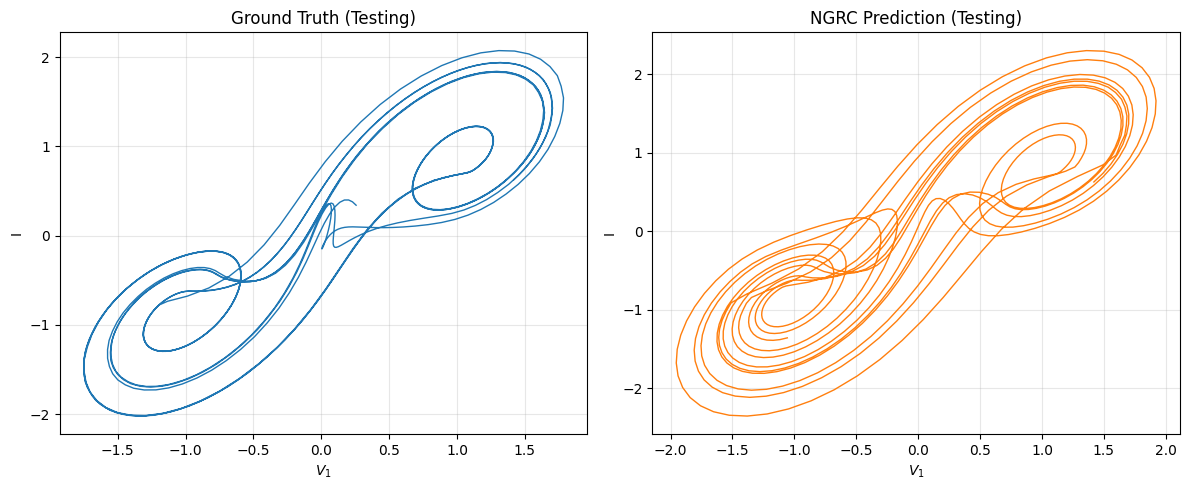

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

true_V1 = doublescroll_soln.y[0,
    warmtrain_pts:warmtrain_pts+plottime_pts]

true_I = doublescroll_soln.y[2,
    warmtrain_pts:warmtrain_pts+plottime_pts]

    
# Extract testing data
true_V1 = doublescroll_soln.y[0,
    warmtrain_pts-1:warmtrain_pts+plottime_pts-1]

true_I = doublescroll_soln.y[2,
    warmtrain_pts-1:warmtrain_pts+plottime_pts-1]

pred_V1 = x_test[0, :plottime_pts]
pred_I  = x_test[2, :plottime_pts]

# Left: Ground Truth
axs[0].plot(true_V1, true_I,
            color='tab:blue',
            linewidth=1)

axs[0].set_title('Ground Truth (Testing)')
axs[0].set_xlabel('$V_1$')
axs[0].set_ylabel('I')
axs[0].grid(alpha=0.3)

# Right: NGRC Prediction
axs[1].plot(pred_V1, pred_I,
            color='tab:orange',
            linewidth=1)

axs[1].set_title('NGRC Prediction (Testing)')
axs[1].set_xlabel('$V_1$')
axs[1].set_ylabel('I')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("img/ds_short_comparision.png", dpi=300)
plt.show()



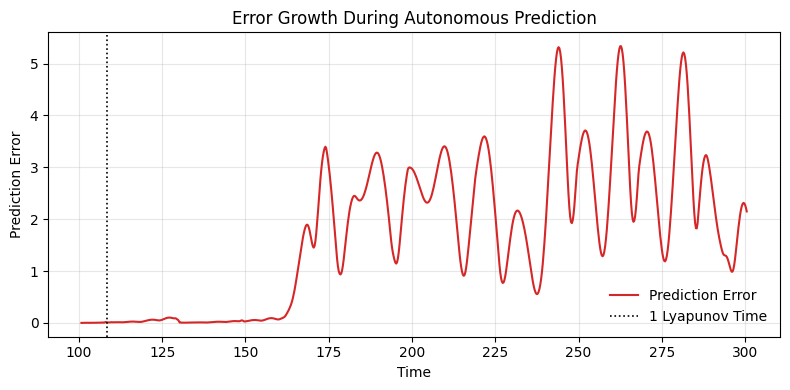

In [20]:
# Compute error magnitude (Euclidean norm at each time step)

true_slice = slice(
    warmtrain_pts - 1,
    warmtrain_pts + plottime_pts - 1
)

# Compute pointwise error between true and predicted trajectories
error = np.sqrt(
    np.sum(
        (
            doublescroll_soln.y[0:d, true_slice]
            - x_test[0:d, :plottime_pts]
        ) ** 2,
        axis=0
    )
)

# Physical time axis corresponding to error
t_error = t_eval[true_slice]

# One Lyapunov time boundary
dt = t_eval[1] - t_eval[0]
t_lyap = t_eval[warmtrain_pts - 1] + lyaptime_pts * dt

# Plot error growth
plt.figure(figsize=(8, 4))

plt.plot(
    t_error,
    error,
    linewidth=1.5,
    color='tab:red',
    label='Prediction Error'
)

plt.axvline(
    t_lyap,
    linestyle=':',
    linewidth=1.2,
    color='black',
    label='1 Lyapunov Time'
)

plt.xlabel("Time")
plt.ylabel("Prediction Error")
plt.title("Error Growth During Autonomous Prediction")
plt.grid(alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("img/ds_total_prediction_error.png", dpi=300)
plt.show()

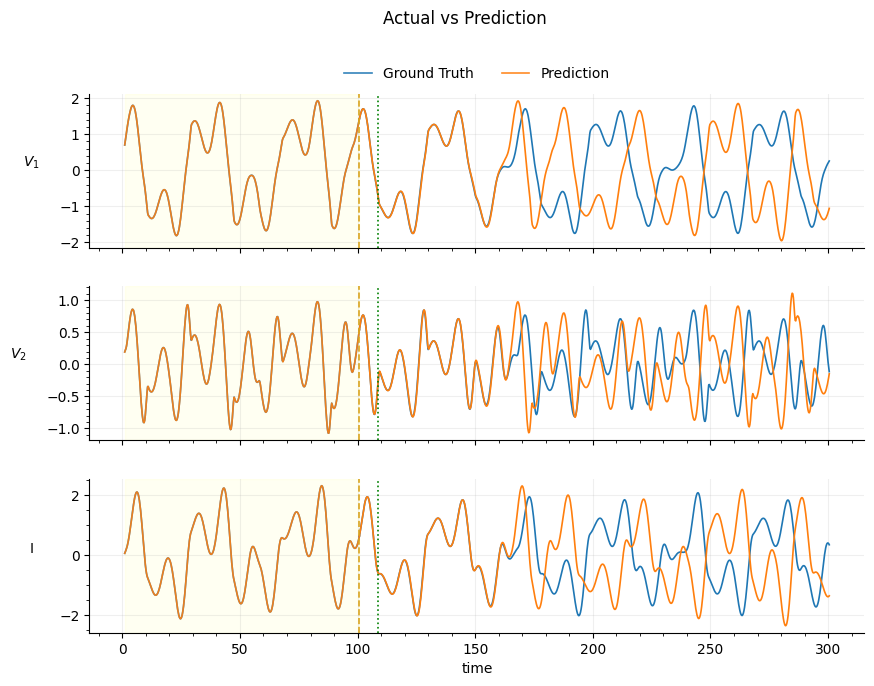

In [21]:
fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

labels = [r'$V_1$', r'$V_2$', 'I']

# Define slices
train_slice = slice(warmup_pts, warmtrain_pts)
test_slice  = slice(
    warmtrain_pts - 1,
    warmtrain_pts + plottime_pts - 1
)

# Time arrays
t_train = t_eval[train_slice]
t_test  = t_eval[test_slice]

# Key time markers
t_boundary = t_eval[warmtrain_pts - 1]
dt_local = t_eval[1] - t_eval[0]
t_lyap = t_boundary + lyaptime_pts * dt_local


for i in range(3):

    # Training region shading
    axs[i].axvspan(
        t_train[0], t_boundary,
        color='yellow', alpha=0.05
    )

    # Training ground truth
    axs[i].plot(
        t_train,
        doublescroll_soln.y[i, train_slice],
        color='tab:blue', linewidth=1.2, alpha=0.9,
        label='Ground Truth' if i == 0 else None
    )

    # Training prediction
    axs[i].plot(
        t_train,
        x_predict[i, :],
        color='tab:orange', linewidth=1.2, alpha=0.9,
        label='Prediction' if i == 0 else None
    )

    # Testing ground truth
    axs[i].plot(
        t_test,
        doublescroll_soln.y[i, test_slice],
        color='tab:blue', linewidth=1.2
    )

    # Testing prediction
    axs[i].plot(
        t_test,
        x_test[i, :plottime_pts],
        color='tab:orange', linewidth=1.2
    )

    # Phase boundaries
    axs[i].axvline(
        t_boundary,
        linestyle='--', color='goldenrod', linewidth=1.2
    )

    axs[i].axvline(
        t_lyap,
        linestyle=':', color='green', linewidth=1.2
    )

    # Styling
    axs[i].grid(True, alpha=0.2)
    axs[i].set_ylabel(labels[i], rotation=0, labelpad=20)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].minorticks_on()


# Legend (top center)
axs[0].legend(
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1),
    ncol=2
)

# Titles and labels
fig.suptitle('Actual vs Prediction', y=1)
axs[2].set_xlabel('time')

plt.subplots_adjust(hspace=0.25)
plt.savefig("img/ds_prediction_error.png", dpi=300)
plt.show()

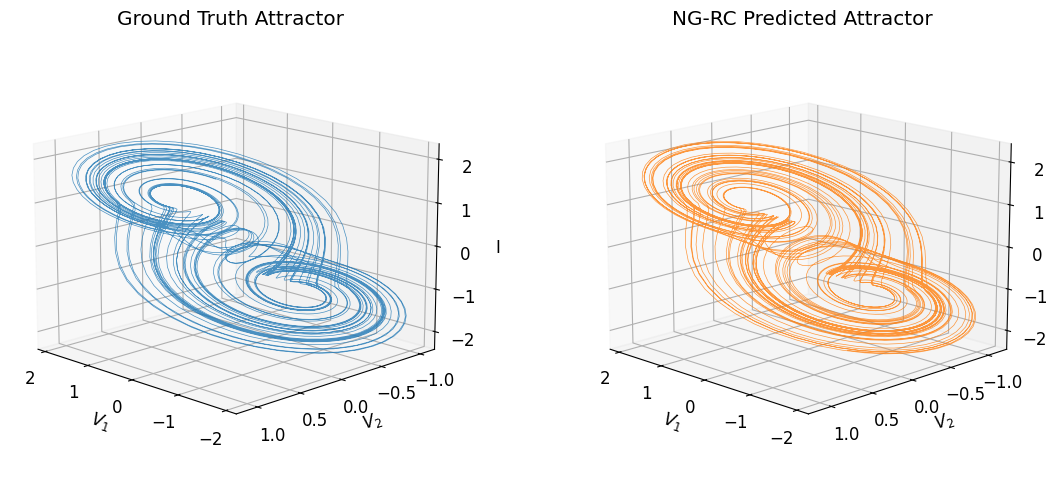

In [22]:
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'font.size': 12})

fig = plt.figure(figsize=(12, 5))


# --- Ground Truth Attractor ---
ax1 = fig.add_subplot(121, projection='3d')

ax1.plot(
    doublescroll_soln.y[0, warmtrain_pts:maxtime_pts],
    doublescroll_soln.y[1, warmtrain_pts:maxtime_pts],
    doublescroll_soln.y[2, warmtrain_pts:maxtime_pts],
    linewidth=0.5,
    color='tab:blue',
    alpha=0.8
)

ax1.set_title('Ground Truth Attractor')
ax1.set_xlabel(r'$V_1$')
ax1.set_ylabel(r'$V_2$')
ax1.set_zlabel('I')
ax1.view_init(elev=15, azim=135)


# --- NG-RC Predicted Attractor ---
ax2 = fig.add_subplot(122, projection='3d')

ax2.plot(
    x_test[0, :],
    x_test[1, :],
    x_test[2, :],
    linewidth=0.5,
    color='tab:orange',
    alpha=0.8
)

ax2.set_title('NG-RC Predicted Attractor')
ax2.set_xlabel(r'$V_1$')
ax2.set_ylabel(r'$V_2$')
ax2.set_zlabel('I')
ax2.view_init(elev=15, azim=135)


# Layout and display
plt.tight_layout()
plt.savefig("img/ds_long_comparision.png", dpi=300)
plt.show()

### Actual vs Predicted Double Scroll Trajectory
```python

%matplotlib notebook

import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 200

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Time settings
frames = plottime_pts
trail = 100

# Physical time window
t_error = t_eval[warmtrain_pts-1 : warmtrain_pts+plottime_pts-1]

# Error computation
dist = np.sqrt(
    np.sum(
        (doublescroll_soln.y[0:3,
            warmtrain_pts-1:warmtrain_pts+plottime_pts-1]
         - x_test[0:3, :plottime_pts])**2,
        axis=0
    )
)

# Lyapunov time marker
dt_local = t_eval[1] - t_eval[0]
t_boundary = t_eval[warmtrain_pts-1]
t_lyap = t_boundary + lyaptime_pts * dt_local

# Create figure
fig = plt.figure(figsize=(13, 6))
fig.suptitle("Actual vs Predicted Double Scroll Trajectory", y=0.98)

# 3D trajectories
ax3d = fig.add_subplot(121, projection='3d')



# Set fixed viewing angle
ax3d.view_init(elev=15, azim=135)


ax3d.set_xlim(np.min(doublescroll_soln.y[0]),
              np.max(doublescroll_soln.y[0]))
ax3d.set_ylim(np.min(doublescroll_soln.y[1]),
              np.max(doublescroll_soln.y[1]))
ax3d.set_zlim(np.min(doublescroll_soln.y[2]),
              np.max(doublescroll_soln.y[2]))

ax3d.set_xlabel(r'$V_1$')
ax3d.set_ylabel(r'$V_2$')
ax3d.set_zlabel('I')

true_line, = ax3d.plot([], [], [],
                       color='tab:blue', lw=2)
true_point, = ax3d.plot([], [], [],
                        'o', color='tab:blue')

pred_line, = ax3d.plot([], [], [],
                       color='tab:orange', lw=2,
                       linestyle='--')
pred_point, = ax3d.plot([], [], [],
                        'o', color='tab:orange')

ax3d.legend([true_line, pred_line],
            ["Ground Truth", "Prediction"],
            loc="upper left")

# Prediction error plot
ax_err = fig.add_subplot(122)

ax_err.set_xlim(t_error[0], t_error[-1])
ax_err.set_ylim(0, np.max(dist) * 1.1)

ax_err.set_title("Prediction Error")
ax_err.set_xlabel("Time")
ax_err.set_ylabel("Euclidean Distance")
ax_err.grid(alpha=0.3)

ax_err.axvline(t_lyap,
               linestyle=':',
               color='tab:green',
               linewidth=1.2)

err_line, = ax_err.plot([], [],
                        color='tab:red',
                        lw=2,
                        alpha=0.8)

# Initialize animation
def init():
    true_line.set_data([], [])
    true_line.set_3d_properties([])
    pred_line.set_data([], [])
    pred_line.set_3d_properties([])
    err_line.set_data([], [])
    return true_line, pred_line, true_point, pred_point, err_line

# Update animation
def update(frame):

    start = max(0, frame - trail)

    # Actual trajectory
    true_line.set_data(
        doublescroll_soln.y[0,
            warmtrain_pts-1+start:warmtrain_pts-1+frame],
        doublescroll_soln.y[1,
            warmtrain_pts-1+start:warmtrain_pts-1+frame]
    )

    true_line.set_3d_properties(
        doublescroll_soln.y[2,
            warmtrain_pts-1+start:warmtrain_pts-1+frame]
    )

    true_point.set_data(
        [doublescroll_soln.y[0, warmtrain_pts-1+frame]],
        [doublescroll_soln.y[1, warmtrain_pts-1+frame]]
    )

    true_point.set_3d_properties(
        [doublescroll_soln.y[2, warmtrain_pts-1+frame]]
    )

    # Predicted trajectory
    pred_line.set_data(
        x_test[0, start:frame],
        x_test[1, start:frame]
    )

    pred_line.set_3d_properties(
        x_test[2, start:frame]
    )

    pred_point.set_data(
        [x_test[0, frame]],
        [x_test[1, frame]]
    )

    pred_point.set_3d_properties(
        [x_test[2, frame]]
    )

    # Error evolution
    err_line.set_data(t_error[:frame],
                      dist[:frame])

    return true_line, pred_line, true_point, pred_point, err_line

# Create animation
ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=30,
    blit=False
)

HTML(ani.to_jshtml())


---
### References

Gauthier, D. J., Bollt, E., Griffith, A., & Barbosa, W. A. S.  
*Next Generation Reservoir Computing*

**Original Code Repository** :  
https://github.com/quantinfo/ng-rc-paper-code

Implementation Repository (This Work):  
https://github.com/Iam-Mak/ng-rc-modeling

**Libraries Used**
- [NumPy](https://numpy.org/)
- [Matplotlib](https://matplotlib.org/)
- [SciPy](https://scipy.org/)

---
---